In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

from unseen import eva
from unseen import similarity

import utils

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/xclim/sdba/__init__.py:22: FutureWarning: The SDBA submodule is in the process of being split from `xclim` in order to facilitate development and effective maintenance of the SDBA utilities. The `xclim.sdba` functionality will change in the future. For more information, please visit https://xsdba.readthedocs.io/en/latest/.
  warnings.warn(


In [2]:
location = 'Katherine'
metric = 'rx1day'

### Observations

In [3]:
da_obs = utils.get_obs_data(metric, location)

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/xstatstests/scipy.py:246: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  outputs = func(args, **scipy_kwargs)
/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/xstatstests/scipy.py:246: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  outputs = func(args, **scipy_kwargs)


In [4]:
df_obs = da_obs.to_dataframe()

In [5]:
ranked_years = df_obs.sort_values(by='pr', ascending=False)
print(ranked_years.head(n=10))

                      lat    lon  event_time          pr
time                                                    
2016-06-30 00:00:00 -15.0  131.5  2015-12-26  121.034966
1957-06-30 00:00:00 -15.0  131.5  1957-03-07  117.113503
1998-06-30 00:00:00 -15.0  131.5  1998-01-27  108.367790
1937-06-30 00:00:00 -15.0  131.5  1937-01-07   79.655670
2000-06-30 00:00:00 -15.0  131.5  2000-03-03   75.046738
1914-06-30 00:00:00 -15.0  131.5  1914-01-04   74.041893
1916-06-30 00:00:00 -15.0  131.5  1915-12-24   73.600754
2005-06-30 00:00:00 -15.0  131.5  2005-01-01   70.866669
2004-06-30 00:00:00 -15.0  131.5  2003-12-23   69.717285
1946-06-30 00:00:00 -15.0  131.5  1946-02-15   69.121651


In [6]:
da_obs_detrended, linear_data_obs = utils.detrend_obs(da_obs)

In [7]:
gev_obs_detrended = eva.fit_gev(da_obs_detrended.values)

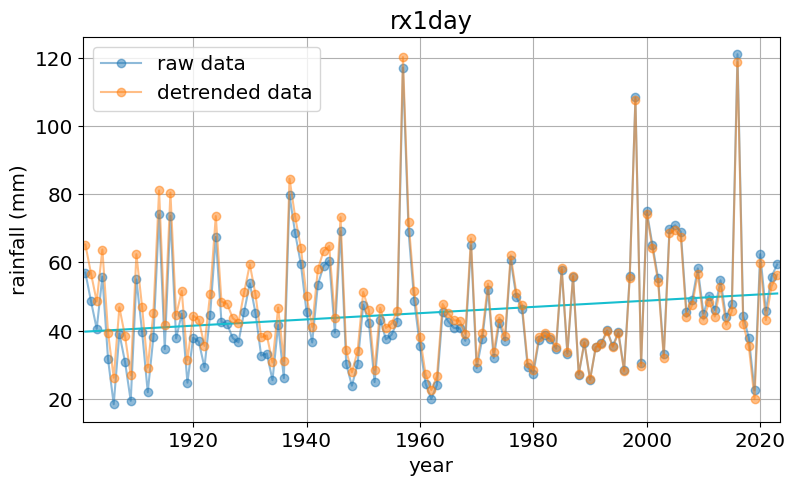

In [8]:
fig, ax = plt.subplots(figsize=[9, 5])
years = da_obs['time'].dt.year.values
plt.plot(years, da_obs.values, marker='o', label='raw data', color='tab:blue', alpha=0.5)
plt.plot(years, linear_data_obs, color='tab:cyan')
plt.plot(years, da_obs_detrended.values, marker='o', label='detrended data', color='tab:orange', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title('rx1day')
plt.ylabel('rainfall (mm)')
plt.xlabel('year')
plt.legend()
plt.grid()

### Model data

TODO: Write loop to go over all models

In [9]:
models = [
    'BCC-CSM2-MR',
    'CAFE',
    'CMCC-CM2-SR5',
    'CanESM5',
    'EC-Earth3',
    'IPSL-CM6A-LR',
    'MIROC6',
    'MPI-ESM1-2-HR',
    'MRI-ESM2-0',
    'NorCPM1',
]

In [12]:
for model in models:
    print(model)
    # Raw model data
    da_model_stacked = utils.get_model_data(metric, model, location)
    da_model_detrended, da_model_detrended_stacked, linear_data_model = utils.detrend_model(da_model_stacked)
    gev_model_detrended = eva.fit_gev(da_model_detrended_stacked.values)
    utils.plot_model_data(da_model_stacked, da_model_detrended_stacked, linear_data_model, metric)
    # Mean correction
    da_model_detrended_bc_mean_stacked = utils.mean_correction(da_model_detrended, da_obs_detrended, metric)
    gev_model_detrended_bc_mean = eva.fit_gev(da_model_detrended_bc_mean_stacked.values)
    # Quantile correction
    da_model_detrended_bc_quantile_stacked = utils.quantile_correction(da_model_detrended_stacked, da_obs_detrended, metric)
    gev_model_detrended_bc_quantile = eva.fit_gev(da_model_detrended_bc_quantile_stacked.values)
    # Plot distributions
    utils.plot_distributions(
        metric,
        location,
        da_obs_detrended,
        gev_obs_detrended,
        da_model_detrended_stacked,
        gev_model_detrended,
        da_model_detrended_bc_mean_stacked,
        gev_model_detrended_bc_mean,
        da_model_detrended_bc_quantile_stacked,
        gev_model_detrended_bc_quantile,
    )
    # Similarity testing
    print('Raw data similarity tests')
    similarity_ds = similarity.similarity_tests(da_model_detrended, da_obs_detrended)
    print('KS score:', similarity_ds['ks_statistic'].values)
    print('KS p-value:', similarity_ds['ks_pval'].values)
    print('AD score:', similarity_ds['ad_statistic'].values)
    print('AD p-value:', similarity_ds['ad_pval'].values)
    print('Mean correction similarity tests')
    utils.fidelity_tests(da_model_detrended, da_obs_detrended, da_model_detrended_bc_mean_stacked.unstack())
    print('Quantile correction similarity tests')
    utils.fidelity_tests(da_model_detrended, da_obs_detrended, da_model_detrended_bc_quantile_stacked.unstack())